# Phase 3 Step 5b — 02b Cross-Sectional 단독 평가 (`05b_eval_crosssec.ipynb`)

> **목적**: 02b Cross-Sectional ensemble (LSTM CS + HAR) 의 변동성 예측 + BL_ml_cs 포트폴리오 성과를
>          **다른 모델·시나리오와 비교 없이 단독으로** 평가한다 + **Ticker Embedding 분석** 추가.
>          비교는 별도 노트북 (`05c_eval_compare.ipynb`) 에서 수행.

## 평가 4 레이어 (05a 와 동일 형식) + CS 특화

| § | Layer | 내용 |
|---|---|---|
| §2 | **Layer 1** | 변동성 예측 진단 (RMSE/QLIKE/MZ/DM-test/Best model) |
| §2-7 | **CS 특화** | Ticker Embedding PCA + Cosine Similarity |
| §3 | **Layer 2** | BL_ml_cs 포트폴리오 단독 |
| §4 | **Layer 3** | ML → BL 인과 추적 |
| §5 | **Layer 4** | 시기별 분해 |
| §6 | 종합 요약 | render_diagnostic_summary 자동 생성 |

## 평가 모듈 (`scripts/diagnostics.py`)
05a 와 동일 함수 호출 → **05a 와 직접 비교 가능** (05c 에서 통합).

## 사전 조건
- ✅ `data/ensemble_predictions_crosssec.csv` (02b 결과)
- ✅ `data/daily_panel.csv`
- ✅ `outputs/03_bl_backtest/returns_BL_ml_cs.csv` (03 결과)


## §1. 환경 부트스트랩 + 결과 로드

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR
import scripts.diagnostics as diag

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '05b_v2_eval_crosssec'  # Phase 3-2 v2
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05b_v2_eval_crosssec


In [2]:
# 02b 결과 로드
ens_cs_path = DATA_DIR / 'ensemble_predictions_crosssec.csv'
assert ens_cs_path.exists(), f'02b 결과 없음: {ens_cs_path}'
ens_cs = pd.read_csv(ens_cs_path, parse_dates=['date'])
print(f'ensemble_cs: {ens_cs.shape}')
print(f'  unique 종목: {ens_cs["ticker"].nunique()}')
print(f'  날짜 범위: {ens_cs["date"].min().date()} ~ {ens_cs["date"].max().date()}')
print(f'  컬럼: {list(ens_cs.columns)}')

# CS 예측 컬럼 자동 감지
if 'y_pred_ensemble' in ens_cs.columns:
    cs_pred_col = 'y_pred_ensemble'
elif 'y_pred_lstm_cs' in ens_cs.columns:
    cs_pred_col = 'y_pred_lstm_cs'
else:
    raise ValueError('y_pred_ensemble 또는 y_pred_lstm_cs 컬럼 없음')
print(f'\n사용 예측 컬럼: {cs_pred_col}')

ensemble_cs: (2635610, 9)
  unique 종목: 615
  날짜 범위: 2007-04-23 ~ 2025-12-01
  컬럼: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm_cs', 'y_pred_har', 'w_lstm_cs', 'w_har', 'y_pred_ensemble']

사용 예측 컬럼: y_pred_ensemble


In [3]:
# Daily panel + Market data
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'vol_21d', 'log_ret', 'log_mcap', 'spy_close'],
)
print(f'panel: {panel.shape}')

market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
spy_daily = market['SPY'].pct_change().dropna()
spy_monthly = (1 + spy_daily).resample('ME').prod() - 1
print(f'spy_monthly: {len(spy_monthly)} 개월')

panel: (3395442, 6)
spy_monthly: 292 개월


In [4]:
# BL_ml_cs 포트폴리오 결과 로드
bl_returns_path = OUTPUTS_DIR / '03_bl_backtest' / 'returns_BL_ml_cs.csv'

if bl_returns_path.exists():
    bl_ml_cs_returns = pd.read_csv(bl_returns_path, index_col=0, parse_dates=True).squeeze()
    print(f'BL_ml_cs returns: {len(bl_ml_cs_returns)} 개월')
    print(f'  기간: {bl_ml_cs_returns.index[0].date()} ~ {bl_ml_cs_returns.index[-1].date()}')
else:
    print(f'⚠️ BL_ml_cs 결과 없음: {bl_returns_path}')
    print('  → 03 노트북 실행 후 본 노트북 §3~§6 재실행 필요')
    bl_ml_cs_returns = None

BL_ml_cs returns: 192 개월
  기간: 2010-01-29 ~ 2025-12-31


## §2. Layer 1 — 02b 변동성 예측 단독 진단

`evaluate_volatility_prediction()` 호출 (05a 와 동일 함수).


In [5]:
# Layer 1 호출
# ⭐ 2026-05-01 fix: 02b 컬럼명 alias 추가 (best_model + weight_timeline panel 활성화)
#   evaluate_volatility_prediction 가 'y_pred_lstm' + 'w_v4' 검사 (02a 명명)
#   02b 컬럼: 'y_pred_lstm_cs' + 'w_lstm_cs' → alias 추가로 6 panel 모두 활성화
ens_cs_alias = ens_cs.copy()
if 'y_pred_lstm_cs' in ens_cs_alias.columns and 'y_pred_lstm' not in ens_cs_alias.columns:
    ens_cs_alias['y_pred_lstm'] = ens_cs_alias['y_pred_lstm_cs']
if 'w_lstm_cs' in ens_cs_alias.columns and 'w_v4' not in ens_cs_alias.columns:
    ens_cs_alias['w_v4'] = ens_cs_alias['w_lstm_cs']

result_cs = diag.evaluate_volatility_prediction(
    pred_df=ens_cs_alias,
    model_name='02b Cross-Sectional Ensemble',
    pred_col=cs_pred_col,
    true_col='y_true',
    har_pred_col='y_pred_har' if 'y_pred_har' in ens_cs_alias.columns else None,
)

# 전체 메트릭 출력
print('=== Layer 1 전체 메트릭 ===')
overall = result_cs['overall']
for k in diag.METRIC_ORDER_PREDICTION:
    if k in overall:
        v = overall[k]
        print(f'  {k:25s} = {v:.4f}' if not np.isnan(v) else f'  {k:25s} = NaN')

=== Layer 1 전체 메트릭 ===
  rmse                      = 0.4117
  qlike                     = 1.9882
  r2_train_mean             = 0.4764
  mz_alpha                  = -0.2529
  mz_beta                   = 0.9333
  mz_r2                     = 0.4800
  pred_std_ratio            = 0.7424
  spearman                  = 0.6667
  dm_stat_vs_har            = -61.4837
  dm_pvalue_vs_har          = 0.0000
  n_pairs                   = 2635610.0000


In [6]:
# 종목별 RMSE 통계 + Best 모델
print('=== 종목별 RMSE 통계 ===')
print(result_cs['by_ticker'][['rmse', 'qlike', 'spearman']].describe())

if len(result_cs['best_model']) > 0:
    print('\n=== Best 모델 분포 ===')
    print(result_cs['best_model'])

=== 종목별 RMSE 통계 ===
            rmse      qlike   spearman
count 615.000000 615.000000 615.000000
mean    0.415976   3.263288   0.449777
std     0.125387  42.681177   0.143550
min     0.308732   0.213865  -0.688722
25%     0.371883   0.379089   0.370182
50%     0.395491   0.448100   0.464131
75%     0.422758   0.556799   0.545597
max     1.983206 958.218213   0.785077

=== Best 모델 분포 ===
Ensemble    330
HAR         217
LSTM         68
Name: count, dtype: int64


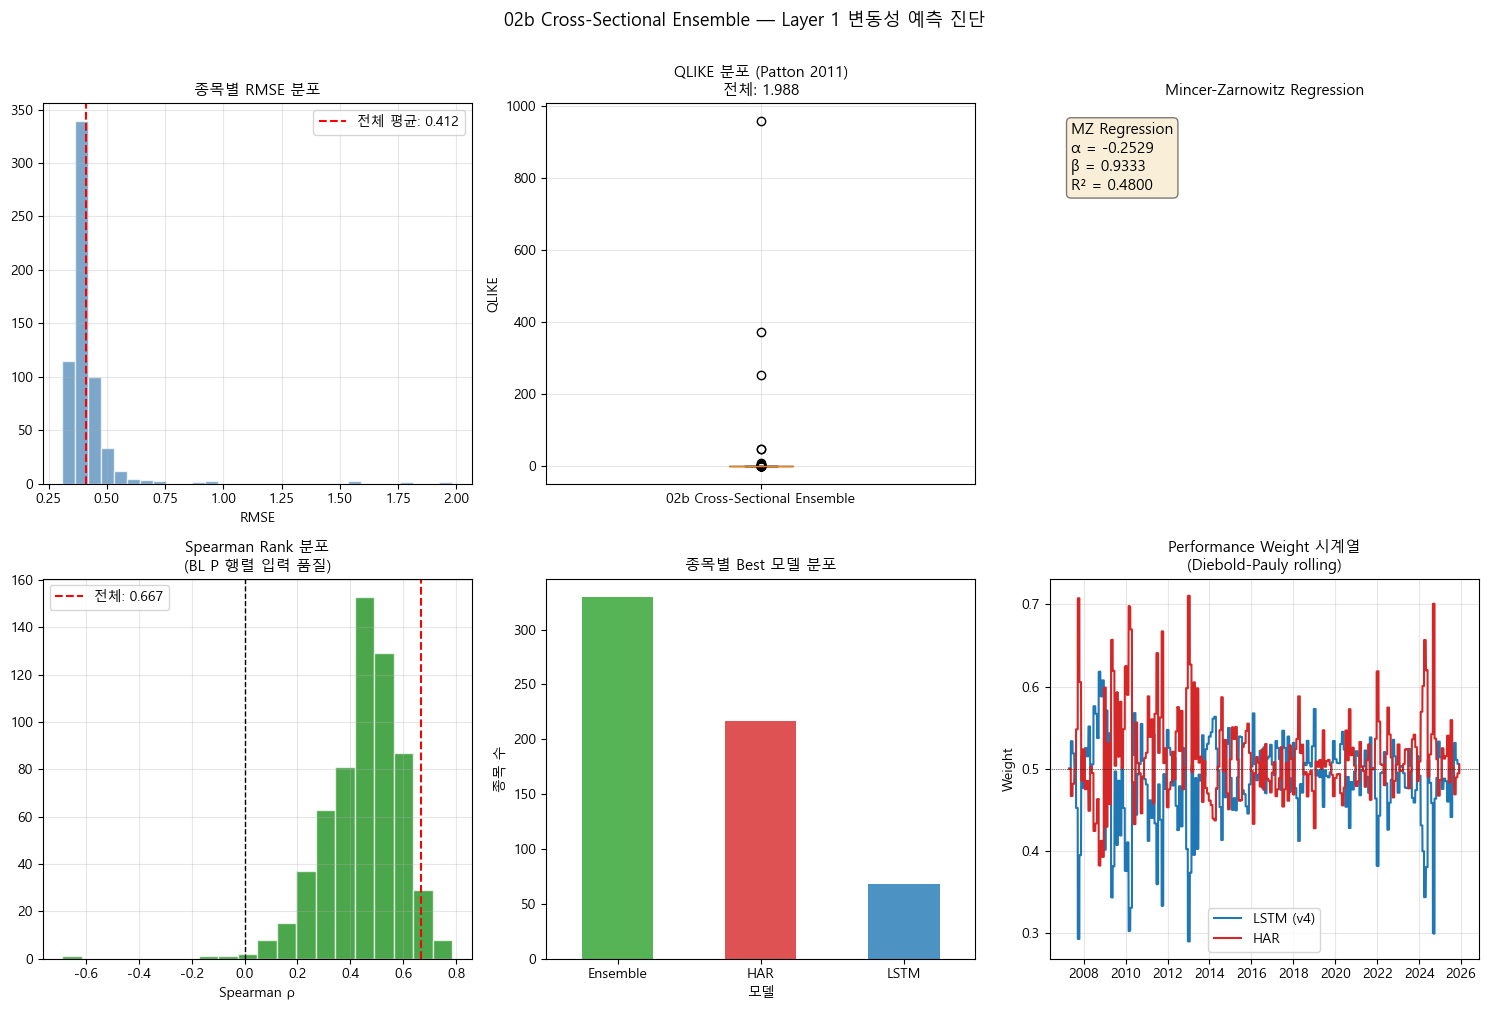

In [7]:
# Layer 1 시각화 (6 panel)
fig = diag.plot_prediction_diagnostic_panel(
    result_cs,
    save_path=OUT_DIR / 'layer1_prediction_diagnostic.png',
)
plt.show()

### §2-7. Cross-Sectional 특화: Ticker Embedding 분석

CS 모델의 핵심 차별 요소는 ticker_embedding 레이어.
- PCA 2D 시각화 → 종목 간 학습된 관계 구조
- Cosine similarity matrix → 비슷한 변동성 패턴 종목 군집
- Embedding norm 분포 → overfitting 진단 (큰 norm = 종목 특화 ↑)


In [8]:
# 학습된 모델 파일 찾기
model_files = list((DATA_DIR / 'models_cs').glob('*.pt')) if (DATA_DIR / 'models_cs').exists() else []

if model_files:
    # 가장 최근 모델
    latest_model = max(model_files, key=lambda p: p.stat().st_mtime)
    print(f'사용 모델: {latest_model.name}')

    from scripts.models_cs import CrossSectionalLSTMRegressor, CS_V4_BEST_CONFIG
    from scripts.volatility_ensemble import build_cs_inputs

    # cs_inputs 재생성 (ticker_to_id 매핑용)
    universe = pd.read_csv(DATA_DIR / 'universe_full_history.csv')
    all_tickers = universe['ticker'].unique().tolist()
    cs_inputs = build_cs_inputs(panel.merge(
        pd.DataFrame({'ticker': all_tickers}), on='ticker'
    ), all_tickers)
    n_tickers = cs_inputs['n_tickers']

    # 모델 로드
    model = CrossSectionalLSTMRegressor(
        input_size=CS_V4_BEST_CONFIG['input_size'],
        hidden_size=CS_V4_BEST_CONFIG['hidden_size'],
        num_layers=CS_V4_BEST_CONFIG['num_layers'],
        dropout=CS_V4_BEST_CONFIG['dropout'],
        n_tickers=n_tickers,
        embedding_dim=CS_V4_BEST_CONFIG['embedding_dim'],
    )
    checkpoint = torch.load(latest_model, map_location='cpu')
    model.load_state_dict(checkpoint.get('model_state_dict', checkpoint))

    # Embedding weight 추출
    emb_weights = model.ticker_embedding.weight.detach().numpy()
    ticker_names = sorted(cs_inputs['ticker_to_id'].keys(),
                          key=lambda t: cs_inputs['ticker_to_id'][t])
    print(f'Embedding shape: {emb_weights.shape}')
    print(f'Embedding norm 통계:')
    norms = np.linalg.norm(emb_weights, axis=1)
    print(f'  min={norms.min():.4f}, mean={norms.mean():.4f}, max={norms.max():.4f}')
else:
    emb_weights = None
    ticker_names = None
    print('⚠️ 학습된 모델 파일 없음 → Embedding 분석 skip')

⚠️ 학습된 모델 파일 없음 → Embedding 분석 skip


In [9]:
# Embedding 시각화 (3 panel)
if emb_weights is not None:
    from sklearn.decomposition import PCA
    from sklearn.metrics.pairwise import cosine_similarity

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. PCA 2D
    ax = axes[0]
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb_weights)
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.5, s=20, color='steelblue')
    # 처음 30개만 label
    for i, t in enumerate(ticker_names[:30]):
        ax.annotate(t, emb_2d[i], fontsize=6, alpha=0.7)
    ax.set_title(f'Ticker Embedding PCA 2D\n(설명력 PC1={pca.explained_variance_ratio_[0]*100:.1f}%, '
                 f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
    ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2'); ax.grid(alpha=0.3)

    # 2. Cosine similarity matrix (sample 50 종목)
    ax = axes[1]
    n_sample = min(50, len(ticker_names))
    sample_idx = np.random.RandomState(42).choice(len(ticker_names), n_sample, replace=False)
    sim_matrix = cosine_similarity(emb_weights[sample_idx])
    im = ax.imshow(sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'Cosine Similarity Matrix\n(sample {n_sample} 종목)', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

    # 3. Norm 분포 (overfitting 진단)
    ax = axes[2]
    ax.hist(norms, bins=30, color='darkgreen', alpha=0.7, edgecolor='white')
    ax.axvline(norms.mean(), color='red', linestyle='--',
               label=f'mean={norms.mean():.3f}')
    ax.set_title('Embedding Norm 분포\n(큰 norm = 종목 특화 ↑, overfitting 진단)', fontsize=11)
    ax.set_xlabel('L2 norm'); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'embedding_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Embedding 시각화 skip')

Embedding 시각화 skip


## §3. Layer 2 — BL_ml_cs 포트폴리오 단독 진단

`evaluate_portfolio_standalone()` 호출 (05a 와 동일 함수).


In [10]:
if bl_ml_cs_returns is not None:
    metrics_l2 = diag.evaluate_portfolio_standalone(
        returns=bl_ml_cs_returns,
        scenario_name='BL_ml_cs',
        spy_returns=spy_monthly,
    )

    print('=== Layer 2 전체 메트릭 ===')
    for k in diag.METRIC_ORDER_PORTFOLIO:
        if k in metrics_l2:
            v = metrics_l2[k]
            unit = '%' if k in ('cagr', 'ann_vol', 'mdd', 'capm_alpha', 'cvar_5', 'var_5', 'hit_rate') else ''
            if isinstance(v, (int, np.integer)):
                print(f'  {k:25s} = {v}')
            elif np.isnan(v):
                print(f'  {k:25s} = NaN')
            else:
                print(f'  {k:25s} = {v:.3f}{unit}')
else:
    metrics_l2 = None
    print('⚠️ BL_ml_cs returns 없음 → Layer 2 skip')

=== Layer 2 전체 메트릭 ===
  sharpe                    = 1.094
  cagr                      = 12.347%
  ann_vol                   = 11.268%
  mdd                       = -17.549%
  capm_alpha                = 17.360%
  capm_beta                 = -0.157
  capm_t                    = 0.207
  information_ratio         = 0.098
  sortino                   = 1.694
  calmar                    = 0.704
  hit_rate                  = 64.583%
  skew                      = -0.365
  kurt                      = 0.539
  cvar_5                    = -6.553%
  var_5                     = -4.565%
  turnover                  = NaN
  top10_concentration       = NaN
  n_months                  = 192


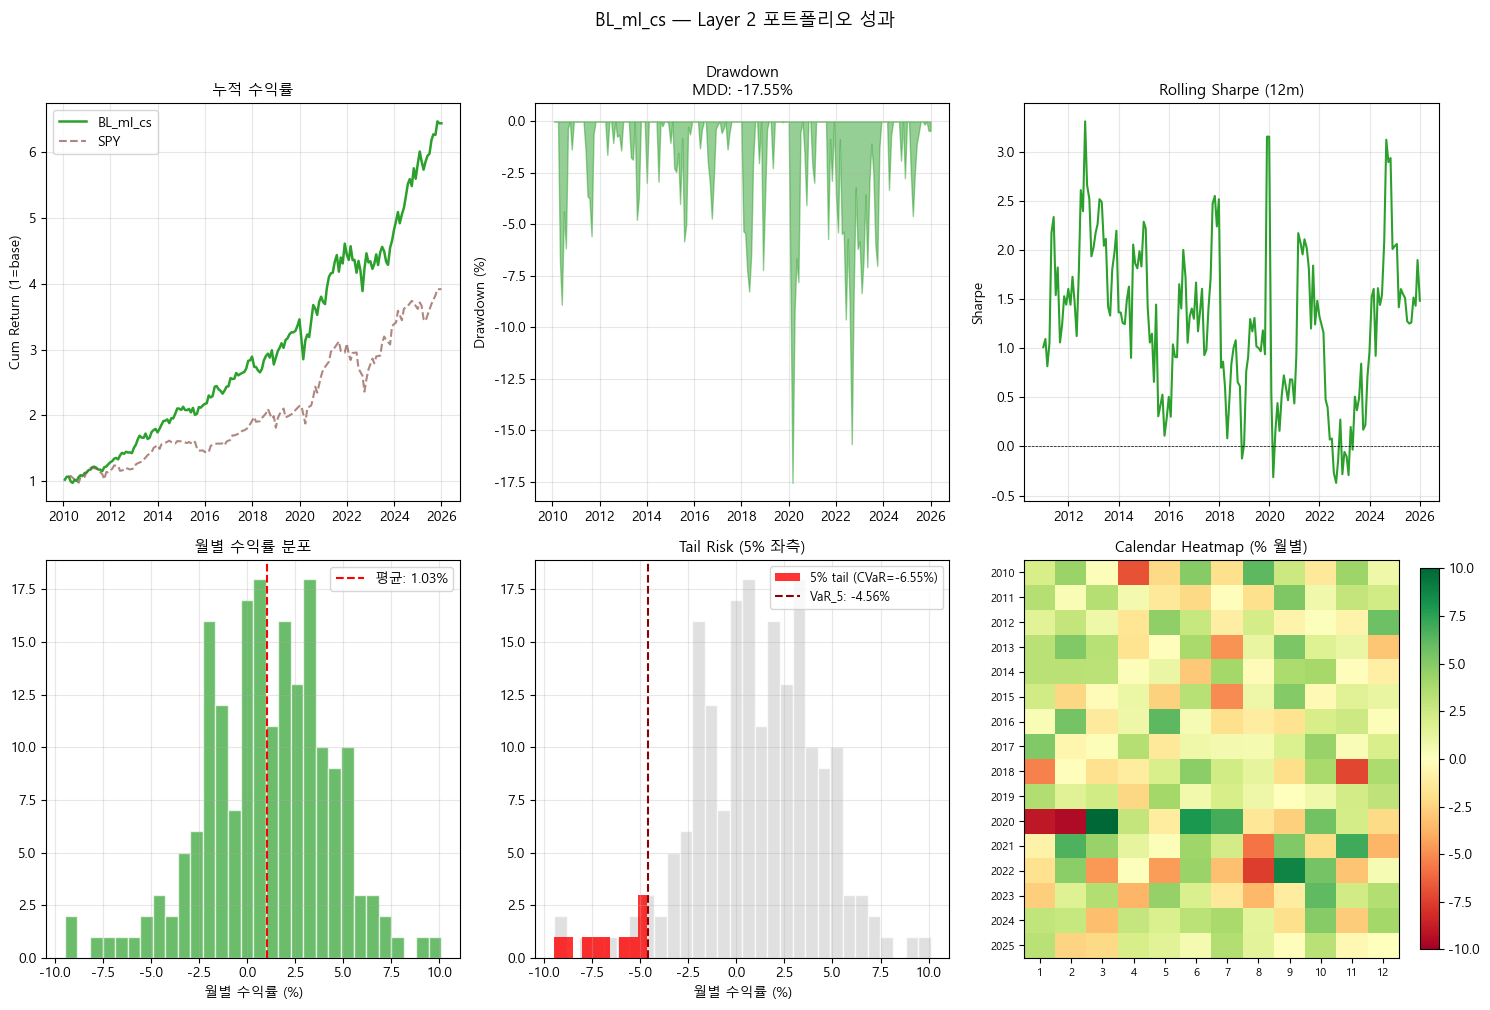

In [11]:
# Layer 2 시각화
if bl_ml_cs_returns is not None:
    fig = diag.plot_portfolio_diagnostic_panel(
        returns=bl_ml_cs_returns,
        scenario_name='BL_ml_cs',
        spy_returns=spy_monthly,
        save_path=OUT_DIR / 'layer2_portfolio_diagnostic.png',
    )
    plt.show()

## §4. Layer 3 — ML → BL 인과 추적

In [12]:
# Layer 3 호출
weights_dict_dummy = {pd.Timestamp(d): pd.Series(dtype=float)
                       for d in ens_cs['date'].unique()}

causality_cs = diag.evaluate_ml_to_bl_pipeline(
    pred_df=ens_cs,
    weights_dict=weights_dict_dummy,
    panel=panel,
    scenario_name='BL_ml_cs',
    pred_col=cs_pred_col,
    pct=0.30,
)

print('=== Layer 3 메트릭 ===')
print(f'  low_vol_hit_rate:  {causality_cs["low_vol_hit_rate"]:.3f} (random=0.30)')
print(f'  high_vol_hit_rate: {causality_cs["high_vol_hit_rate"]:.3f} (random=0.30)')
rc = causality_cs['rank_consistency_timeline']
print(f'  rank_consistency 평균: {rc.mean():.3f} (n={len(rc)} 시점)')
tov = causality_cs['p_matrix_turnover']
print(f'  P 행렬 turnover 평균: {tov.mean():.3f} (n={len(tov)} 시점)')

=== Layer 3 메트릭 ===
  low_vol_hit_rate:  0.695 (random=0.30)
  high_vol_hit_rate: 0.716 (random=0.30)
  rank_consistency 평균: 0.765 (n=4684 시점)
  P 행렬 turnover 평균: 0.091 (n=4683 시점)


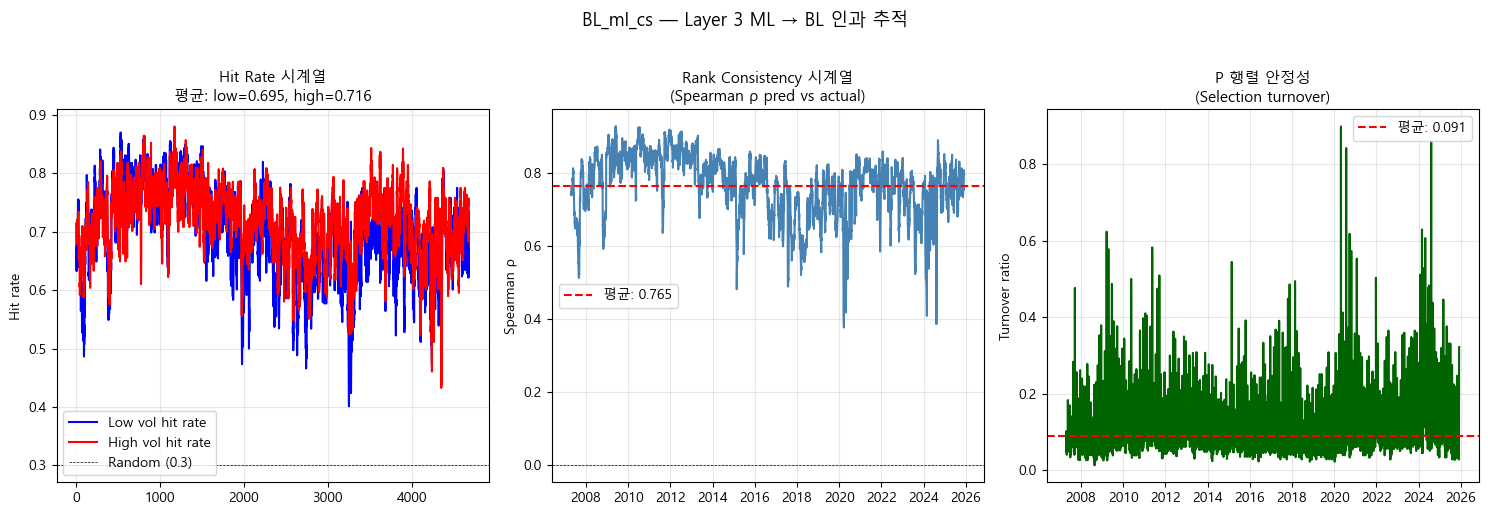

In [13]:
# Layer 3 시각화
fig = diag.plot_ml_bl_diagnostic_panel(
    causality_cs,
    scenario_name='BL_ml_cs',
    save_path=OUT_DIR / 'layer3_ml_to_bl_causality.png',
)
plt.show()

## §5. Layer 4 — 시기별 분해 (5 시기)

In [14]:
# Layer 4 호출 — BL_ml_cs 시기별 분해
if bl_ml_cs_returns is not None:
    period_metrics_cs = diag.evaluate_by_period(
        returns_dict={'BL_ml_cs': bl_ml_cs_returns},
        periods=diag.PERIODS,
        spy_returns=spy_monthly,
    )

    print('=== Layer 4 시기별 메트릭 (BL_ml_cs) ===')
    key_metrics = ['sharpe', 'cagr', 'mdd', 'sortino', 'capm_alpha', 'hit_rate']
    if not period_metrics_cs.empty:
        period_table = period_metrics_cs['BL_ml_cs'].unstack('metric')
        if not period_table.empty:
            display_cols = [c for c in key_metrics if c in period_table.columns]
            print(period_table[display_cols].round(3).to_string())
else:
    period_metrics_cs = None
    print('⚠️ BL_ml_cs returns 없음 → Layer 4 skip')

=== Layer 4 시기별 메트릭 (BL_ml_cs) ===
metric           sharpe      cagr        mdd  sortino  capm_alpha  hit_rate
period                                                                     
COVID 충격 (20)  0.438000  7.586000  -9.466000 0.719000         NaN 50.000000
GFC 회복 (09~11) 1.237000 13.321000  -8.898000 1.913000   18.448000 66.667000
긴축·전환 (21~22)  0.567000  8.012000 -15.667000 1.294000   11.265000 58.333000
정상 강세장 (12~19) 1.424000 13.190000  -8.256000 2.139000   16.536000 67.708000
회복·AI (23~25)  1.464000 14.040000  -5.989000 3.375000   19.257000 63.889000


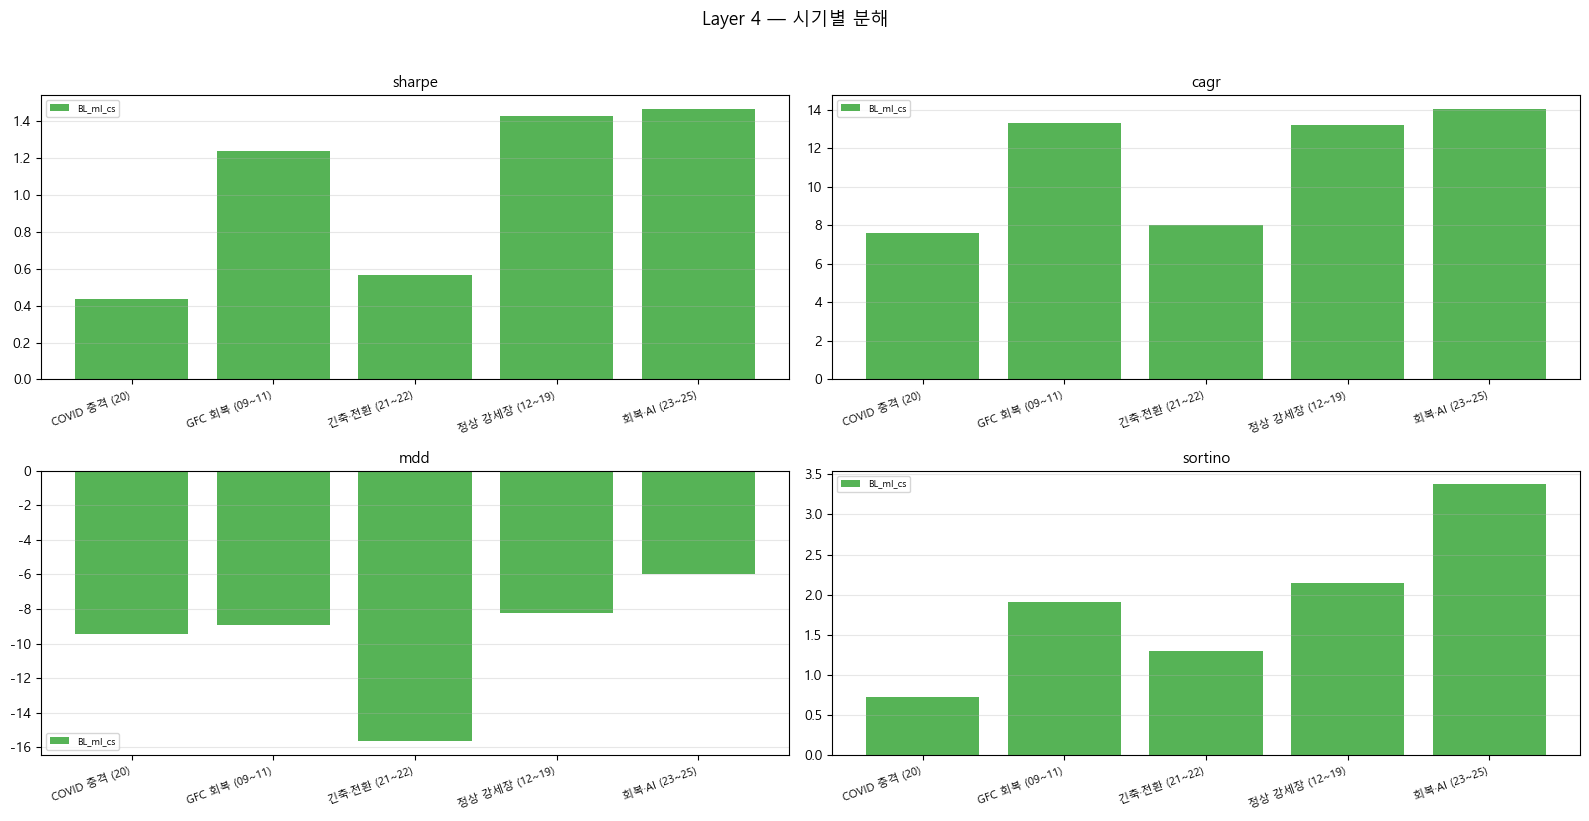

In [15]:
# Layer 4 시각화
if bl_ml_cs_returns is not None and period_metrics_cs is not None and not period_metrics_cs.empty:
    fig = diag.plot_period_decomposition(
        period_metrics=period_metrics_cs,
        metrics_to_plot=['sharpe', 'cagr', 'mdd', 'sortino'],
        save_path=OUT_DIR / 'layer4_period_decomposition.png',
    )
    plt.show()

## §6. 종합 요약 + 결과 저장

In [16]:
# 종합 요약 markdown
layers_for_summary = {'layer1': result_cs}
if metrics_l2 is not None:
    layers_for_summary['layer2'] = metrics_l2
layers_for_summary['layer3'] = causality_cs

summary_md = diag.render_diagnostic_summary(
    model_name='02b Cross-Sectional (BL_ml_cs)',
    layer_results=layers_for_summary,
)

print(summary_md)

summary_path = OUT_DIR / 'eval_summary_crosssec.md'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_md)
print(f'\n✅ 저장: {summary_path}')

# 02b Cross-Sectional (BL_ml_cs) — 종합 진단 보고서

## Layer 1 — 변동성 예측 진단

- RMSE: 0.4117
- QLIKE: 1.9882
- R²_train_mean: 0.4764
- MZ: α=-0.2529, β=0.9333, R²=0.4800
- pred_std_ratio: 0.742 (mean-collapse 진단)
- Spearman: 0.667
- DM-test vs HAR: stat=-61.484, p=0.0000

## Layer 2 — 포트폴리오 단독 성과

- Sharpe: 1.094
- CAGR: 12.35%
- MDD: -17.55%
- Sortino: 1.694
- Calmar: 0.704
- CAPM α: 17.36% (β=-0.157, t=0.21)
- Information ratio: 0.098
- Hit rate: 64.6%
- CVaR_5: -6.55%

## Layer 3 — ML → BL 인과 추적

- Low vol hit rate: 0.695 (random=0.30)
- High vol hit rate: 0.716
- Rank consistency 평균: 0.765
- P 행렬 turnover 평균: 0.091


✅ 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05b_v2_eval_crosssec\eval_summary_crosssec.md


In [17]:
# 메트릭 JSON 저장 (05c 비교에서 재사용)
import json

eval_results = {
    'model_name': '02b Cross-Sectional',
    'layer1_overall': {k: (None if isinstance(v, float) and np.isnan(v) else v)
                        for k, v in result_cs['overall'].items()},
    'layer2_metrics': {} if metrics_l2 is None else {
        k: (None if isinstance(v, float) and np.isnan(v) else (
            int(v) if isinstance(v, (np.integer, int)) else float(v)
        ))
        for k, v in metrics_l2.items()
    },
    'layer3_metrics': {
        'low_vol_hit_rate': float(causality_cs['low_vol_hit_rate']),
        'high_vol_hit_rate': float(causality_cs['high_vol_hit_rate']),
        'rank_consistency_mean': float(causality_cs['rank_consistency_timeline'].mean())
                                  if len(causality_cs['rank_consistency_timeline']) > 0 else None,
        'p_matrix_turnover_mean': float(causality_cs['p_matrix_turnover'].mean())
                                   if len(causality_cs['p_matrix_turnover']) > 0 else None,
    },
}

json_path = OUT_DIR / 'eval_metrics_crosssec.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=2)
print(f'✅ 저장: {json_path}')

print('\n=== Phase 3 Step 5b 완료 ===')
print('다음 단계: 05c_eval_compare.ipynb (시나리오 간 비교 + 통계 검정)')

✅ 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05b_v2_eval_crosssec\eval_metrics_crosssec.json

=== Phase 3 Step 5b 완료 ===
다음 단계: 05c_eval_compare.ipynb (시나리오 간 비교 + 통계 검정)
